# TF_CVXPY_PP demo

Visual demo of the parametric-penalty trend filtering density estimator.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.sampler.truncated_gmm import TruncatedGMM
from utils.sampler.truncated_normal import TruncatedNormal
from utils.sampler.sinusoidal import Sinusoidal
from utils.sampler.step_function import StepFunction

from methods.non_HAL_method.TF_CVXPY_PP.estimator import (
    TrendFilteringCVXPYParametricPenaltyEstimator,
)

np.random.seed(7)


## Simulated data

We use a simple mixture on [0, 1] for visualization.


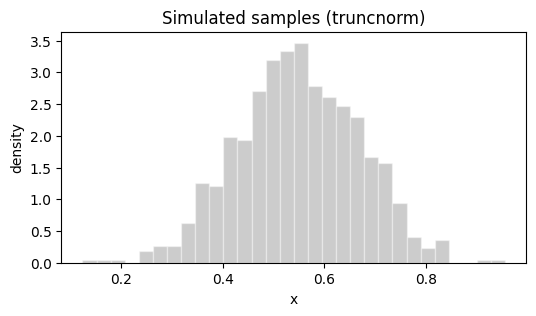

In [2]:
# DGP choice: "truncnorm", "gmm", "sinusoidal", "step", "gs5"
dgp_name = "truncnorm"

n = 800

DGP_CHOICES = ["truncnorm", "gmm", "sinusoidal", "step", "gs5"]


def create_dgp(name: str):
    if name == "truncnorm":
        return TruncatedNormal(mean=0.55, std=0.12, lower=0.0, upper=1.0)

    if name == "gmm":
        return TruncatedGMM(
            components=[
                {"mean": 0.2, "std": 0.05, "lower": 0.0, "upper": 1.0},
                {"mean": 0.5, "std": 0.05, "lower": 0.0, "upper": 1.0},
                {"mean": 0.8, "std": 0.05, "lower": 0.0, "upper": 1.0},
            ],
            weights=[0.33, 0.34, 0.33],
        )

    if name == "gs5":
        spike_means = [0.45, 0.475, 0.50, 0.525, 0.55]
        components = [
            {"mean": m, "std": 0.005, "lower": 0.0, "upper": 1.0} for m in spike_means
        ]
        components.append({"mean": 0.50, "std": 0.05, "lower": 0.0, "upper": 1.0})
        weights = [1.0 / 15.0] * 5 + [2.0 / 3.0]
        return TruncatedGMM(components=components, weights=weights)

    if name == "sinusoidal":
        return Sinusoidal()

    if name == "step":
        return StepFunction(level1=1.5, level2=0.5, breakpoint=0.4)

    raise ValueError(f"Unknown DGP: {name}. Choose from {DGP_CHOICES}")


sampler = create_dgp(dgp_name)
np.random.seed(7)

x = sampler.generate_samples(int(n))
x = np.asarray(x, dtype=float)
x = np.clip(x, 0.0, 1.0)

# DataFrame in the expected format

sample_df = pd.DataFrame({"W1": x})

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(x, bins=30, density=True, alpha=0.4, color="gray", edgecolor="white")
ax.set_title(f"Simulated samples ({dgp_name})")
ax.set_xlabel("x")
ax.set_ylabel("density")
plt.show()


## Fit parametric-penalty TF

We anchor `theta[0]=0` and penalize the full falling-factorial coefficient vector.


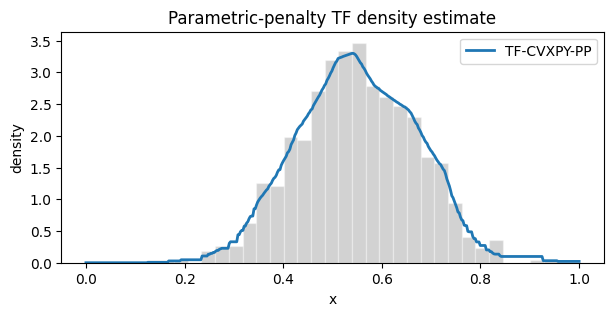

In [3]:
estimator = TrendFilteringCVXPYParametricPenaltyEstimator(
    k=1,
    lam=0.05,
    n_grid_points=400,
    solver="MOSEK",
    use_secondary_solver=True,
)

estimator.fit(sample_df)

grid, density = estimator.get_density()

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(x, bins=30, density=True, alpha=0.35, color="gray", edgecolor="white")
ax.plot(grid, density, color="tab:blue", lw=2, label="TF-CVXPY-PP")
ax.set_title("Parametric-penalty TF density estimate")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
plt.show()


## Inspect the penalty transform

This shows the size of the `H_inv` operator and the resulting coefficient vector.


In [4]:
if estimator.hinv is None or estimator.theta_hat is None:
    raise ValueError("Estimator not fitted or missing H_inv/theta_hat.")

Hinv = estimator.hinv
alpha = Hinv @ estimator.theta_hat

print("H_inv shape:", Hinv.shape)
print("alpha shape:", alpha.shape)
print("alpha (first 10):", np.round(alpha[:10], 4))


H_inv shape: (801, 801)
alpha shape: (801,)
alpha (first 10): [ 0.00000e+00  5.20557e+01 -1.40862e+01 -1.84091e+01 -9.00000e-04
 -2.00000e-03 -2.80000e-03 -1.90000e-03 -1.10000e-03 -6.00000e-04]


## Optuna CV comparison (TF-CVXPY vs TF-CVXPY-PP)

This runs a small Optuna CV search for both estimators and plots the best fits.


Initialized tuner for TrendFilteringCVXPYEstimator
Dataset size: 800 samples
Cross-validation: 3 folds
Optimization metric: sll (maximize)

Starting hyperparameter optimization...
Estimator: TrendFilteringCVXPYEstimator
Trials: 10
Metric: sll


Optimizing TrendFilteringCVXPYEstimator: 100%|██████████| 10/10 [00:01<00:00,  8.59trial/s, Best SLL: 0.6724]



Optimization completed!
Best SLL: 0.672419
Best parameters:
  k: 2
  norm_constraint: 0.034254459026333825

Fitting best model on full dataset...
Parameters: {'k': 2, 'norm_constraint': 0.034254459026333825}
Best model fitted successfully!

Evaluating best model...
Final model evaluation:
  Sum Log-Likelihood: 0.707440
  BIC: 4222.470048
  Selected knots: N/A
Initialized tuner for TrendFilteringCVXPYPP
Dataset size: 800 samples
Cross-validation: 3 folds
Optimization metric: sll (maximize)

Starting hyperparameter optimization...
Estimator: TrendFilteringCVXPYPP
Trials: 10
Metric: sll


Optimizing TrendFilteringCVXPYPP:  40%|████      | 4/10 [00:19<00:17,  2.98s/trial, Best SLL: 0.6468]

WARNING - large complementary slackness residual: 0.000109


Optimizing TrendFilteringCVXPYPP:  50%|█████     | 5/10 [00:46<00:58, 11.75s/trial, Best SLL: 0.6468]

WARNING - large complementary slackness residual: 0.000093


Optimizing TrendFilteringCVXPYPP: 100%|██████████| 10/10 [01:08<00:00,  6.80s/trial, Best SLL: 0.6822]



Optimization completed!
Best SLL: 0.682166
Best parameters:
  k: 1
  norm_constraint: 42.47270739805823

Fitting best model on full dataset...
Parameters: {'k': 1, 'norm_constraint': 42.47270739805823}
Best model fitted successfully!

Evaluating best model...
Final model evaluation:
  Sum Log-Likelihood: 0.694703
  BIC: 4242.849134
  Selected knots: N/A


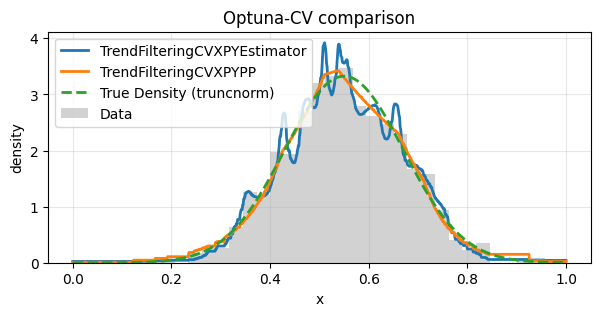

In [6]:
from cross_validation.optuna_hyperparam_selector import (
    OptunaHyperparameterTuner,
    THREEPEAKS_SAMPLER_CONFIG,
)
from utils.sampler.truncated_gmm import TruncatedGMM

# Small trial count for a quick demo; increase for better results
N_TRIALS = 10
CV_FOLDS = 3
METRIC = "sll"  # or "bic"

sampler_setup = {
    "sampler": "TruncatedGMM",
    "sampler_params": THREEPEAKS_SAMPLER_CONFIG,
}

estimator_names = ["TrendFilteringCVXPYEstimator", "TrendFilteringCVXPYPP"]
results = {}

for name in estimator_names:
    tuner = OptunaHyperparameterTuner(
        estimator_name=name,
        data=sample_df,
        sampler_setup=sampler_setup,
        cv_folds=CV_FOLDS,
        metric=METRIC,
        n_grid_points=200,
        silent=False,
        show_progress=True,
    )
    tuner.optimize(n_trials=N_TRIALS, show_progress=True)
    best_estimator = tuner.fit_best_model()
    tuner.evaluate_best_model(best_estimator, save_plot=False)
    results[name] = best_estimator

# Plot comparison
plt.figure(figsize=(7, 3))
for name, estimator in results.items():
    grid_points, density = estimator.get_density()
    plt.plot(grid_points, density, linewidth=2, label=name)

true_sampler = create_dgp(dgp_name)
true_density = true_sampler.compute_density(grid_points)
plt.plot(grid_points, true_density, linestyle="--", linewidth=2, label=f"True Density ({dgp_name})")

plt.hist(sample_df["W1"], bins=30, density=True, alpha=0.35, color="gray", label="Data")
plt.title("Optuna-CV comparison")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
